# ML-testbed 12 — train a small language model to call tools

Now LM means language model. Train a tiny causal Transformer from scratch to produce a structured tool call from an experiment request. Learn tokenization, embeddings, causal attention, next-token loss, answer masking, generation and constrained output.

This is a deliberately small command language, not a pretrained assistant. Its limitations are useful because the complete training loop fits on the screen.

## How to use this lesson
Run from the top with **Python (Factor AI)** or the environment in `docs/WORLD_MODEL_COURSE.md`. Each notebook runs independently; later notebooks reuse the small `ml_testbed` package. No API calls or model downloads occur. Training uses the CPU to make the default run portable.

**Skills:** causal language modeling, token vocabulary, response-only loss, autoregressive generation, structured outputs

**Evidence contract:** all saved results are exposed synthetic development evidence. Train, tuning, calibration and evaluation draws have separate seeds where used. Re-running and tuning on these evaluation draws makes them development data; they are not a secret final test. Never split frames from one shot across train and evaluation.

**Scope:** a dimensionless, pre-stagnation Z-inspired teaching model. It is not a calibrated digital twin of Sandia's Z machine. The thermal and perturbation variables are proxies; they do not identify phase, ETI, MRTI, or fusion performance.

In [1]:
from pathlib import Path
import sys, json, copy, time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from dataclasses import asdict, replace
from IPython.display import display
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'ml_testbed').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from the ML-testbed repo, with ml_testbed/ beside notebooks/.')
sys.path.insert(0, str(ROOT))
from ml_testbed.world import *
from ml_testbed.learning import seed_all, fit, save_run, grid_posterior, weighted_interval, entropy
seed_all(42)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2})
DEVICE = torch.device('cpu')
print('PyTorch', torch.__version__, '| CPU | dimensionless teaching world v1')

PyTorch 2.14.0 | CPU | dimensionless teaching world v1


## 1. The language and its supervision
A prompt encodes a question, available current/motion channels, and timing calibration. A completion is JSON containing one tool name. Twenty-four semantic cases are partitioned into 16 training, four tuning, and four evaluation cases. These small counts are for learning the machinery, not establishing general language understanding.

The labels are an authored workflow policy: obtain missing information, request a timing calibration when required, then infer. A growth question needs imaging because the summary operator cannot observe growth.

In [2]:
from ml_testbed.language import TinyToolLM, VOCAB, TOKEN, partitions, batch, lm_loss, prompt, answer, expected_tool, generate, parse_call, constrained_call
train,dev,evaluation=partitions()
print('Vocabulary:',VOCAB)
print('Prompt:',prompt(train[0])); print('Answer:',answer(expected_tool(train[0])))
x,y=batch(train); xd,yd=batch(dev)
print('Token tensor shape:',x.shape,'| scored response positions:',int((y[0]!=-100).sum()))
print('Target tokens (-100 are ignored):',y[0].tolist())

Vocabulary: ['<pad>', '<bos>', '<eos>', 'question', 'mass', 'growth', 'charge', 'current', 'motion', 'present', 'missing', 'clock', 'calibrated', 'unknown', '->', '{', '"tool"', ':', '}', '"infer"', '"align"', '"request_current"', '"request_motion"', '"request_image"']
Prompt: <bos> question mass current present motion present clock unknown ->
Answer: { "tool" : "align" } <eos>
Token tensor shape: torch.Size([16, 15]) | scored response positions: 6
Target tokens (-100 are ignored): [-100, -100, -100, -100, -100, -100, -100, -100, -100, 15, 16, 17, 20, 18, 2]


### Visual lab — The model predicts the next token, not the token it just read

The upper strip is the input sequence; the lower strip is its one-position-shifted target. Pale targets are prompt positions ignored by the loss. Orange targets are response tokens that contribute to training, including the end token.

**Notice:** the prompt is still visible as context even though its reconstruction is not scored.

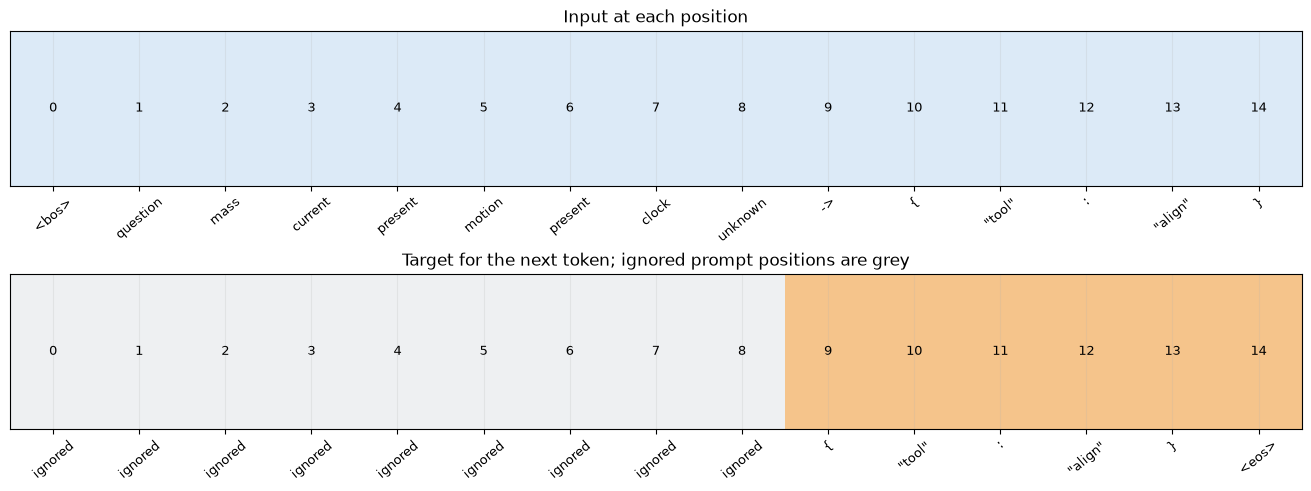

In [3]:
from matplotlib.colors import ListedColormap
v_input=x[0].numpy(); v_target=y[0].numpy(); v_length=len(v_input)
v_fig,v_axes=plt.subplots(2,1,figsize=(13,4.8),layout='constrained')
v_axes[0].imshow(np.zeros((1,v_length)),aspect='auto',cmap=ListedColormap(['#dceaf7']))
v_axes[1].imshow((v_target!=-100)[None,:],aspect='auto',cmap=ListedColormap(['#eef0f2','#f5c48b']),vmin=0,vmax=1)
for v_ax,v_tokens,v_title in zip(v_axes,[v_input,v_target],['Input at each position','Target for the next token; ignored prompt positions are grey']):
    v_labels=[VOCAB[int(v_token)] if v_token!=-100 else 'ignored' for v_token in v_tokens]
    v_ax.set(xticks=range(v_length),xticklabels=v_labels,yticks=[],title=v_title)
    v_ax.tick_params(axis='x',labelrotation=40,labelsize=9)
    for v_i in range(v_length): v_ax.text(v_i,0,str(v_i),ha='center',va='center',fontsize=9)
plt.show()

## 2. Causal attention and response masking do different jobs
The causal mask prevents a position from looking at future answer tokens. The `-100` loss labels stop us from scoring prompt reconstruction. The prompt still supplies context. During generation, no correct response tokens are supplied.

Unlike a normal text tokenizer, this vocabulary uses whitespace-separated tokens and treats each tool name as one token. That keeps the lesson small but limits transfer to real prose.

In [4]:
import inspect
print(inspect.getsource(TinyToolLM))
model=TinyToolLM()
print('Trainable parameters:',sum(p.numel() for p in model.parameters()))
model.eval()
with torch.no_grad():
    original=model(x[:1]); altered=x[:1].clone(); altered[0,-1]=TOKEN['missing']; changed=model(altered)
causal_error=float((original[:,:-1]-changed[:,:-1]).abs().max())
assert causal_error<1e-6
print('Earlier logits unchanged by changing final input token:',causal_error)

class TinyToolLM(nn.Module):
    def __init__(self,width=32):
        super().__init__(); self.embedding=nn.Embedding(len(VOCAB),width)
        self.position=nn.Embedding(32,width)
        layer=nn.TransformerEncoderLayer(width,2,64,dropout=0,batch_first=True)
        self.transformer=nn.TransformerEncoder(layer,1,enable_nested_tensor=False)
        self.head=nn.Linear(width,len(VOCAB))
    def forward(self,ids):
        n=ids.shape[1]; positions=torch.arange(n,device=ids.device)
        causal=torch.triu(torch.ones(n,n,device=ids.device,dtype=torch.bool),diagonal=1)
        return self.head(self.transformer(self.embedding(ids)+self.position(positions),mask=causal))

Trainable parameters: 11128
Earlier logits unchanged by changing final input token: 0.0


### Visual lab — A causal mask prevents peeking ahead

A blue square means a query at the row position may read the column position. The upper triangle is blocked because those tokens are in the future. This is the **permission mask**, not a learned attention-weight matrix.

**Notice:** causal masking and response-loss masking solve different problems. One limits available information; the other decides which errors are scored.

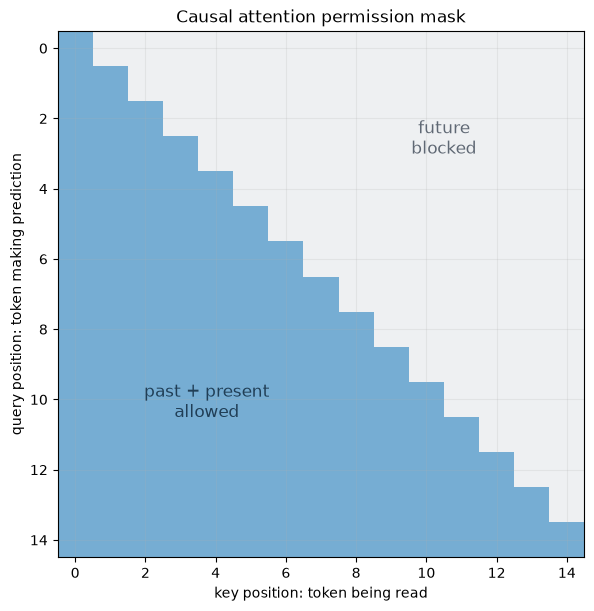

In [5]:
from matplotlib.colors import ListedColormap
v_n=x.shape[1]; v_allowed=np.tril(np.ones((v_n,v_n)))
v_fig,v_ax=plt.subplots(figsize=(7,6),layout='constrained')
v_ax.imshow(v_allowed,cmap=ListedColormap(['#eef0f2','#76add3']),vmin=0,vmax=1)
v_ax.set(xlabel='key position: token being read',ylabel='query position: token making prediction',title='Causal attention permission mask',xticks=np.arange(0,v_n,2),yticks=np.arange(0,v_n,2))
v_ax.text(v_n*.7,v_n*.2,'future\nblocked',ha='center',fontsize=12,color='#5f6874')
v_ax.text(v_n*.25,v_n*.7,'past + present\nallowed',ha='center',fontsize=12,color='#203e56')
plt.show()

## 3. The language-model training loop
Forward computes token logits. Cross entropy scores only response tokens. Backward computes gradients. AdamW adjusts the Transformer. Select the checkpoint using tuning loss, then generate on semantic cases absent from training. This is actual local LM training; no external model or service is used.

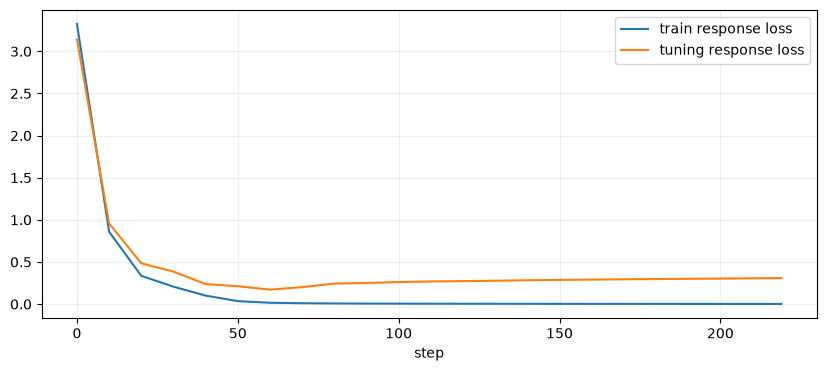

In [6]:
seed_all(12); model=TinyToolLM(); optimizer=torch.optim.AdamW(model.parameters(),lr=.004)
best=float('inf'); checkpoint=copy.deepcopy(model.state_dict()); history=[]
STEPS=220
for step in range(STEPS):
    model.train(); optimizer.zero_grad(); logits=model(x); loss=lm_loss(logits,y)
    loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1.0); optimizer.step()
    if step%10==0 or step==STEPS-1:
        model.eval()
        with torch.no_grad(): val=float(lm_loss(model(xd),yd))
        history.append((step,float(loss.detach()),val))
        if val<best: best=val; checkpoint=copy.deepcopy(model.state_dict())
model.load_state_dict(checkpoint); model.eval()
h=np.array(history); plt.plot(h[:,0],h[:,1],label='train response loss'); plt.plot(h[:,0],h[:,2],label='tuning response loss'); plt.legend(); plt.xlabel('step'); plt.show()

## 4. Compare unconstrained generation with valid-call scoring
Unconstrained greedy generation can emit malformed JSON or the wrong action. Constrained scoring ranks only complete valid JSON calls. It guarantees the limited syntax, not the right decision. We keep both scores and retain failures. The baseline always calls `infer`; it may look successful on easy cases while failing missing-data cases.

In [7]:
rows=[]
for case in evaluation:
    text=generate(model,case); parsed=parse_call(text); constrained=constrained_call(model,case)
    expected=expected_tool(case)
    rows.append({'case':case,'expected':expected,'generated':text,'valid':parsed is not None,
                 'raw_correct':parsed is not None and parsed['tool']==expected,
                 'constrained_correct':constrained['tool']==expected,'constrained_tool':constrained['tool'],
                 'always_infer_correct':expected=='infer'})
display(rows)
metrics={key:sum(int(r[key]) for r in rows)/len(rows) for key in ['valid','raw_correct','constrained_correct','always_infer_correct']}
metrics['evaluation_cases']=len(rows)
print(metrics)

[{'case': {'question': 'charge',
   'current': False,
   'motion': False,
   'clock': False},
  'expected': 'request_current',
  'generated': '{ "tool" : "request_current" }',
  'valid': True,
  'raw_correct': True,
  'constrained_correct': True,
  'constrained_tool': 'request_current',
  'always_infer_correct': False},
 {'case': {'question': 'mass',
   'current': False,
   'motion': False,
   'clock': True},
  'expected': 'request_current',
  'generated': '{ "tool" : "request_current" }',
  'valid': True,
  'raw_correct': True,
  'constrained_correct': True,
  'constrained_tool': 'request_current',
  'always_infer_correct': False},
 {'case': {'question': 'mass',
   'current': False,
   'motion': True,
   'clock': True},
  'expected': 'request_current',
  'generated': '{ "tool" : "request_current" }',
  'valid': True,
  'raw_correct': True,
  'constrained_correct': True,
  'constrained_tool': 'request_current',
  'always_infer_correct': False},
 {'case': {'question': 'charge',
   'curr

{'valid': 1.0, 'raw_correct': 0.75, 'constrained_correct': 0.75, 'always_infer_correct': 0.25, 'evaluation_cases': 4}


### Visual lab — Watch autoregressive generation one token at a time

At each step the LM assigns probabilities to the next token, chooses the largest one, appends it, and repeats. The bars show the top five tokens at that step for the first held-out request. Playback is saved with the notebook; a static view of the tool-name step appears first.

**Notice:** these are next-token probabilities inside a tiny command language. They are not calibrated probabilities that a scientific decision is correct.

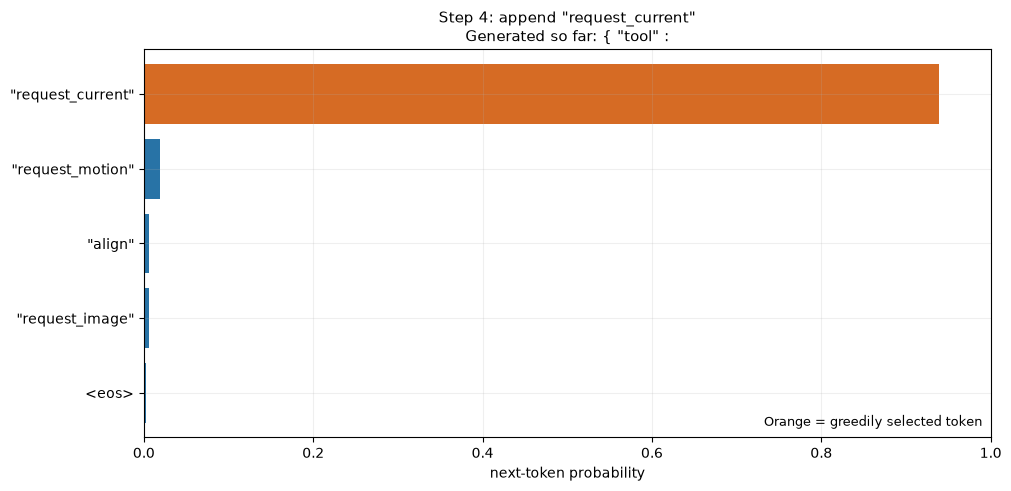

In [8]:
from ml_testbed.language import encode
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import textwrap as v_textwrap
v_case=evaluation[0]; v_prefix=encode(prompt(v_case)); v_ids=v_prefix.copy(); v_generation=[]
with torch.no_grad():
    for v_step in range(8):
        v_prob=model(torch.tensor([v_ids]))[0,-1].softmax(-1)
        v_probabilities,v_tokens=torch.topk(v_prob,5)
        v_next=int(v_prob.argmax())
        v_generation.append({'before':v_ids[len(v_prefix):].copy(),'tokens':v_tokens.tolist(),'probabilities':v_probabilities.tolist(),'chosen':v_next})
        v_ids.append(v_next)
        if v_next==TOKEN['<eos>']: break
v_fig,v_ax=plt.subplots(figsize=(10,4.8),layout='constrained')
def v_update_tokens(v_index):
    v_ax.clear(); v_frame=v_generation[v_index]
    v_names=[VOCAB[v_token] for v_token in v_frame['tokens']]
    v_colors=['#d66b24' if v_token==v_frame['chosen'] else '#2873a6' for v_token in v_frame['tokens']]
    v_ax.barh(np.arange(5),v_frame['probabilities'],color=v_colors)
    v_ax.set(yticks=np.arange(5),yticklabels=v_names,xlim=(0,1),ylim=(4.6,-.6),xlabel='next-token probability')
    v_so_far=' '.join(VOCAB[v_token] for v_token in v_frame['before']) or '(nothing yet)'
    v_ax.set_title(f'Step {v_index+1}: append {VOCAB[v_frame["chosen"]]}\nGenerated so far: {v_so_far}',fontsize=11)
    v_ax.text(.99,.03,'Orange = greedily selected token',transform=v_ax.transAxes,ha='right',fontsize=9)
    return []
v_update_tokens(min(3,len(v_generation)-1)); display(v_fig)
v_token_movie=FuncAnimation(v_fig,v_update_tokens,frames=len(v_generation),interval=900,blit=False)
v_token_html=v_token_movie.to_jshtml(default_mode='once'); plt.close(v_fig); display(HTML(v_token_html))

## 5. Save and reload the actual learned weights
A reproducible checkpoint includes vocabulary and model configuration, not just floating-point weights. Loading this file in another process should preserve predictions. The saved weights are a teaching model, not Factor's existing Qwen adapter.

In [9]:
run=save_run(ROOT,'12',metrics,{'steps':STEPS,'seed':12,'train_cases':16,'tuning_cases':4,'evaluation_cases':4})
torch.save({'state_dict':model.state_dict(),'vocabulary':VOCAB,'width':32},run/'tiny_tool_lm.pt')
loaded=TinyToolLM(); checkpoint=torch.load(run/'tiny_tool_lm.pt',map_location='cpu',weights_only=True)
assert checkpoint['vocabulary']==VOCAB
loaded.load_state_dict(checkpoint['state_dict']); loaded.eval()
assert generate(loaded,evaluation[0])==generate(model,evaluation[0])
(run/'generated_evaluation.json').write_text(json.dumps(rows,indent=2))
print('Reload verified:',run)

Reload verified: /Users/operator/Desktop/Factor/runs/world-model/12-424b8a244b


## Bridge to a pretrained LM
The same next-token loss, prompt masking and evaluation logic also apply to a pretrained model. Factor's existing PyTorch lab uses a small Qwen model and LoRA; that is a natural next experiment after this notebook. Keep the tool schema fixed while changing model/provider. A real text tokenizer, chat template, adapter target modules and context length then become explicit configuration. Do not claim transfer until the new model is evaluated on fresh requests.

## Your next experiments

Write a prediction, change one thing, and save both successes and failures.

1. Repeat with three initialization seeds and report every held-out decision, not just average loss.
2. Add voltage and imaging availability to the language, then split by semantic request families.
3. Compare base and LoRA-tuned local models using the same tool interface and a fresh authored evaluation set.